# Quickstart: NOAA HRRR forecast 48 hour (virtual) — skew-T diagram
A brief introduction to building a **skew-T log-P diagram** from the NOAA HRRR 48 hour
forecast, using the vertical `pressure_level` group of the dataset transformed into an
analysis-ready, cloud-optimized format by dynamical.org.

Unlike the surface-level [quickstart](noaa-hrrr-forecast-48-hour.ipynb), this notebook uses
the **virtual** variant of the dataset. "Virtual" means the Icechunk store holds *references*
into NOAA's original GRIB2 archive rather than a re-encoded copy of the data — the bytes are
decoded on read by the `gribberish` zarr codec. This variant exposes the full set of upper-air
variables on 39 isobaric levels (1000–50 hPa) in a `pressure_level` group, which is exactly what
we need for a vertical sounding.

The virtual dataset is currently published in the **staging** STAC catalog:
https://stac-staging.dynamical.org/catalog.json

Dataset documentation: https://dynamical.org/catalog/noaa-hrrr-forecast-48-hour/

In [ ]:
# If running locally, follow README.md for simple dependency installation.
# If using Google Colab, run this cell.
!uv pip install "dynamical-catalog" "zarr>=3.2" gribberish metpy rioxarray pyproj
# zarr>=3.2 ships the built-in `scale_offset` codec and `gribberish` decodes the virtual
# GRIB chunk references (both are needed to read the virtual store); metpy draws the
# skew-T; rioxarray and pyproj handle the HRRR Lambert Conformal projection.

## Open the `pressure_level` group

The virtual dataset lives in the staging STAC catalog, so we point the `dynamical-catalog`
client there before the first request. We then open the dataset's `pressure_level` group,
whose variables carry a `pressure_level` dimension of 39 isobaric levels.

In [2]:
import dynamical_catalog

# The "virtual" HRRR dataset is currently published in the staging STAC catalog.
# Repoint the client at staging before the first catalog request.
dynamical_catalog._stac.STAC_CATALOG_URL = "https://stac-staging.dynamical.org/catalog.json"

# Optional: identify your requests in the User-Agent header.
# dynamical_catalog.identify("your-name@example.com")

# `open()` passes keyword arguments through to xarray.open_zarr(), so we can select
# the "pressure_level" group directly. Its variables span 39 isobaric levels.
ds = dynamical_catalog.open(
    "noaa-hrrr-forecast-48-hour-virtual", group="pressure_level", chunks=None
)
ds

<xarray.Dataset> Size: 5PB
Dimensions:                   (init_time: 11679, lead_time: 49, y: 1059,
                               x: 1799, pressure_level: 39)
Coordinates:
  * init_time                 (init_time) datetime64[ns] 93kB 2018-07-13T12:0...
    expected_forecast_length  (init_time) timedelta64[us] 93kB ...
  * lead_time                 (lead_time) timedelta64[us] 392B 00:00:00 ... 2...
    valid_time                (init_time, lead_time) datetime64[ns] 5MB ...
  * y                         (y) float64 8kB 1.587e+06 1.584e+06 ... -1.587e+06
  * x                         (x) float64 14kB -2.698e+06 ... 2.696e+06
    latitude                  (y, x) float32 8MB ...
    longitude                 (y, x) float32 8MB ...
  * pressure_level            (pressure_level) int64 312B 1000 975 950 ... 75 50
    spatial_ref               int64 8B ...
Data variables: (12/14)
    absolute_vorticity        (init_time, lead_time, y, x, pressure_level) float64 340TB ...
    dew_point_temperature     (init_time, lead_time, y, x, pressure_level) float64 340TB ...
    cloud_mixing_ratio        (init_time, lead_time, y, x, pressure_level) float64 340TB ...
    graupel                   (init_time, lead_time, y, x, pressure_level) float64 340TB ...
    cloud_ice_mixing_ratio    (init_time, lead_time, y, x, pressure_level) float64 340TB ...
    geopotential_height       (init_time, lead_time, y, x, pressure_level) float64 340TB ...
    ...                        ...
    temperature               (init_time, lead_time, y, x, pressure_level) float64 340TB ...
    wind_u                    (init_time, lead_time, y, x, pressure_level) float64 340TB ...
    vertical_velocity         (init_time, lead_time, y, x, pressure_level) float64 340TB ...
    relative_humidity         (init_time, lead_time, y, x, pressure_level) float64 340TB ...
    snow_mixing_ratio         (init_time, lead_time, y, x, pressure_level) float64 340TB ...
    wind_v                    (init_time, lead_time, y, x, pressure_level) float64 340TB ...
Attributes:
    dataset_id:           noaa-hrrr-forecast-48-hour-virtual
    dataset_version:      0.5.0
    name:                 NOAA HRRR forecast, 48 hour, virtual
    description:          Weather forecasts from the High-Resolution Rapid Re...
    attribution:          NOAA NWS NCEP HRRR data processed by dynamical.org ...
    license:              CC-BY-4.0
    spatial_domain:       Continental United States
    spatial_resolution:   3 km
    time_domain:          Forecasts initialized 2018-07-13 12:00:00 UTC to Pr...
    time_resolution:      Forecasts initialized every 6 hours
    forecast_domain:      Forecast lead time 0-48 hours ahead
    forecast_resolution:  Hourly

## Extract a vertical profile at a point

A skew-T needs a single vertical column: pressure, temperature, dew point, and (optionally)
wind at each level. HRRR data is on a Lambert Conformal grid, so we use `pyproj` to convert a
longitude/latitude point into the dataset's projected `x`/`y` coordinates, then pull the whole
`pressure_level` column for one forecast (`init_time`) and lead time.

In [3]:
import rioxarray  # registers the .rio accessor used to read the dataset CRS
from pyproj import Transformer

# Convert a lon/lat point to the dataset's projected x/y coordinates.
lon, lat = -97.5, 35.4  # near Norman / Oklahoma City, OK
to_grid = Transformer.from_crs("EPSG:4326", ds.rio.crs, always_xy=True)
x, y = to_grid.transform(lon, lat)

# Pick one forecast and lead time, and load the full vertical column.
profile = (
    ds[["temperature", "dew_point_temperature", "wind_u", "wind_v"]]
    .sel(init_time="2024-05-06T00", x=x, y=y, method="nearest")
    .sel(lead_time="0h")
    .load()
)
profile

<xarray.Dataset> Size: 2kB
Dimensions:                   (pressure_level: 39)
Coordinates:
  * pressure_level            (pressure_level) int64 312B 1000 975 950 ... 75 50
    expected_forecast_length  timedelta64[us] 8B 2 days
    lead_time                 timedelta64[us] 8B 00:00:00
    init_time                 datetime64[ns] 8B 2024-05-06
    latitude                  float32 4B 35.4
    longitude                 float32 4B -97.51
    y                         float64 8B -3.453e+05
    x                         float64 8B -520.1
    valid_time                datetime64[ns] 8B 2024-05-06
    spatial_ref               int64 8B 0
Data variables:
    temperature               (pressure_level) float64 312B 21.07 ... -60.8
    dew_point_temperature     (pressure_level) float64 312B 17.04 ... -273.1
    wind_u                    (pressure_level) float64 312B -3.941 ... 3.396
    wind_v                    (pressure_level) float64 312B 0.5068 ... 4.917
Attributes:
    dataset_id:           noaa-hrrr-forecast-48-hour-virtual
    dataset_version:      0.5.0
    name:                 NOAA HRRR forecast, 48 hour, virtual
    description:          Weather forecasts from the High-Resolution Rapid Re...
    attribution:          NOAA NWS NCEP HRRR data processed by dynamical.org ...
    license:              CC-BY-4.0
    spatial_domain:       Continental United States
    spatial_resolution:   3 km
    time_domain:          Forecasts initialized 2018-07-13 12:00:00 UTC to Pr...
    time_resolution:      Forecasts initialized every 6 hours
    forecast_domain:      Forecast lead time 0-48 hours ahead
    forecast_resolution:  Hourly

## Draw the skew-T

We hand the profile to [MetPy](https://unidata.github.io/MetPy/)'s `SkewT`, which draws the
temperature and dew-point curves on skewed temperature / log-pressure axes with the standard
dry adiabats, moist adiabats, and mixing-ratio lines. We also lift a surface-based parcel to
show its path (and the resulting CAPE / CIN and LCL), and add wind barbs.

Each variable carries a CF `units` attribute (e.g. `degree_Celsius`, `m s-1`, and `hPa` on the
`pressure_level` coordinate), so we let MetPy's `.metpy` accessor read those units directly via
`quantify()` rather than attaching them by hand. Two small data-prep notes remain:
- The stored `dew_point_temperature` decodes to about −273.15 °C where upper-level moisture is
  effectively absent, so we mask those unphysical values before plotting.
- Winds are converted from m s⁻¹ to knots for the barbs.

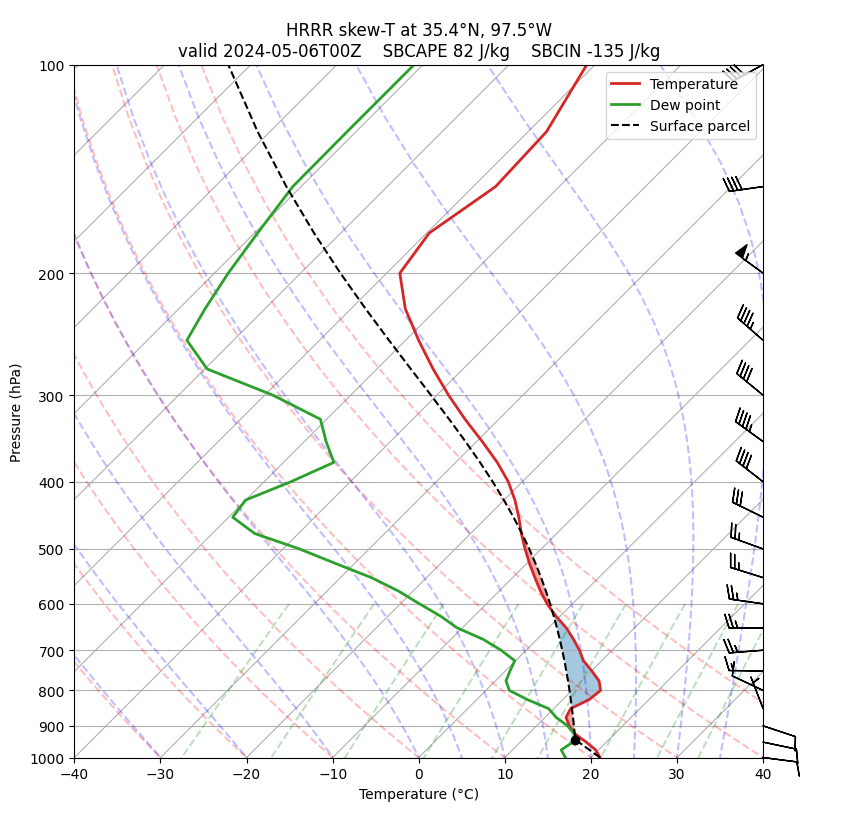

In [4]:
import numpy as np
import matplotlib.pyplot as plt
import metpy.calc as mpcalc
from metpy.plots import SkewT

# MetPy reads units straight from each variable's CF `units` attribute.
prof = profile.metpy.quantify()
p = prof["pressure_level"].metpy.unit_array
T = prof["temperature"].metpy.unit_array
Td = prof["dew_point_temperature"].metpy.unit_array
u = prof["wind_u"].metpy.unit_array.to("knots")
v = prof["wind_v"].metpy.unit_array.to("knots")
# Mask dew points that decode to ~-273.15 °C where upper-level moisture is absent.
Td = np.where(Td.magnitude < -120, np.nan, Td.magnitude) * Td.units

fig = plt.figure(figsize=(9, 9))
skew = SkewT(fig, rotation=45)

# Temperature and dew-point profiles.
skew.plot(p, T, "tab:red", lw=2, label="Temperature")
skew.plot(p, Td, "tab:green", lw=2, label="Dew point")

# Wind barbs (every other level to reduce clutter).
skew.plot_barbs(p[::2], u[::2], v[::2])

# Surface-based parcel path, LCL, and CAPE / CIN.
parcel = mpcalc.parcel_profile(p, T[0], Td[0]).to("degC")
skew.plot(p, parcel, "k", lw=1.5, ls="--", label="Surface parcel")
lcl_p, lcl_t = mpcalc.lcl(p[0], T[0], Td[0])
skew.plot(lcl_p, lcl_t, "ko", markerfacecolor="black")
skew.shade_cape(p, T, parcel)
skew.shade_cin(p, T, parcel, Td)
cape, cin = mpcalc.surface_based_cape_cin(p, T, Td)

# Reference lines and limits.
skew.plot_dry_adiabats(alpha=0.25)
skew.plot_moist_adiabats(alpha=0.25)
skew.plot_mixing_lines(alpha=0.25)
skew.ax.set_ylim(1000, 100)
skew.ax.set_xlim(-40, 40)
skew.ax.set_xlabel("Temperature (°C)")
skew.ax.set_ylabel("Pressure (hPa)")

valid = np.datetime_as_string(profile["valid_time"].values, unit="h")
skew.ax.set_title(
    f"HRRR skew-T at {lat:.1f}°N, {abs(lon):.1f}°W\n"
    f"valid {valid}Z    SBCAPE {cape.m:.0f} J/kg    SBCIN {cin.m:.0f} J/kg"
)
skew.ax.legend(loc="upper right")
plt.show()